# Évaluation du pré-entraînement : Stage 1 vs Stage 2

Comparaison de la structuration sémantique du latent (encodeur MedVAE stage 1 vs encodeur adapté par JEPA stage 2) sur de l'imagerie médicale MedMNIST.

In [1]:
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
import medmnist
from medmnist import INFO
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

ROOT = "/home/infres/yrothlin-24/projet_IM06"
sys.path.insert(0, f"{ROOT}/jepa_adaptation")
from utils.launch import bootstrap, load_config
bootstrap()
from models.medvae import MVAE
from models.mvae_jepa import MVAE_JEPA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
cfg = load_config(f"{ROOT}/jepa_adaptation/configs/stage_2.yaml", f"{ROOT}/jepa_adaptation/configs/model.yaml")
mcfg, jcfg = cfg["model"], cfg["jepa"]

def build_mvae():
    return MVAE(
        ddconfig=mcfg["ddconfig"],
        embed_dim=int(mcfg["embed_dim"]),
        spatial_dims=int(mcfg["spatial_dims"]),
        apply_channel_ds=bool(mcfg["apply_channel_ds"]),
    )

stage1 = build_mvae()
stage1.load_weights(f"{ROOT}/jepa_adaptation/outputs/stage1/best.pt")
stage1 = stage1.model.to(device).eval()

jepa = MVAE_JEPA(
    build_mvae(),
    patch_size=int(jcfg["patch_size"]),
    target_mask_ratio=float(jcfg["target_mask_ratio"]),
    predictor_hidden_dim=jcfg["predictor_hidden_dim"],
    predictor_depth=int(jcfg["predictor_depth"]),
    ema_momentum=float(jcfg["ema_momentum"]),
    sample_posterior=bool(jcfg["sample_posterior"]),
    freeze_decoder=bool(jcfg["freeze_decoder"]),
)
ckpt = torch.load(f"{ROOT}/jepa_adaptation/outputs/stage2/best.pt", map_location="cpu")
jepa.load_state_dict(ckpt["model"], strict=False)
stage2 = jepa.context_encoder.autoencoder.to(device).eval()

making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 56, 56) = 12544 dimensions.
making attention of type 'vanilla' with 512 in_channels
[MVAE] loaded /home/infres/yrothlin-24/projet_IM06/jepa_adaptation/outputs/stage1/best.pt (0 missing, 0 unexpected)
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 56, 56) = 12544 dimensions.
making attention of type 'vanilla' with 512 in_channels


In [3]:
DATASET = "pathmnist"
SIZE = 224
N_TRAIN = 3000
N_TEST = 3000
POOL = 4

def build_eval(split):
    info = INFO[DATASET]
    DataClass = getattr(medmnist, info["python_class"])
    tf = transforms.Compose([
        transforms.Grayscale(1),
        transforms.ToTensor(),
        transforms.Resize((SIZE, SIZE), antialias=True),
        transforms.Normalize([0.5], [0.5]),
    ])
    root = os.path.expanduser("~/.medmnist")
    kw = dict(split=split, transform=tf, download=True, root=root, as_rgb=False)
    try:
        return DataClass(size=SIZE, **kw)
    except TypeError:
        return DataClass(**kw)

def subset(ds, n):
    g = torch.Generator().manual_seed(42)
    idx = torch.randperm(len(ds), generator=g)[:min(n, len(ds))].tolist()
    return Subset(ds, idx)

train_loader = DataLoader(subset(build_eval("train"), N_TRAIN), batch_size=64, num_workers=4)
test_loader = DataLoader(subset(build_eval("test"), N_TEST), batch_size=64, num_workers=4)
len(train_loader.dataset), len(test_loader.dataset)

(3000, 3000)

In [4]:
@torch.no_grad()
def extract(ae, loader):
    feats, labels = [], []
    for x, y in loader:
        x = x.to(device).float()
        z, _, latent = ae.compute_latent_proj(x, sample_posterior=False)
        rep = latent if latent is not None else z
        rep = torch.nn.functional.adaptive_avg_pool2d(rep, POOL).flatten(1)
        feats.append(rep.float().cpu().numpy())
        labels.append(np.asarray(y).reshape(-1))
    return np.concatenate(feats), np.concatenate(labels)

In [5]:
def evaluate(ae):
    Xtr, ytr = extract(ae, train_loader)
    Xte, yte = extract(ae, test_loader)
    sc = StandardScaler().fit(Xtr)
    Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
    lr = LogisticRegression(max_iter=2000).fit(Xtr, ytr)
    knn = KNeighborsClassifier(n_neighbors=20).fit(Xtr, ytr)
    metrics = {
        "linear_probe": float(lr.score(Xte, yte)),
        "knn": float(knn.score(Xte, yte)),
        "silhouette": float(silhouette_score(Xte, yte)),
    }
    return metrics, Xte, yte

m1, X1, y1 = evaluate(stage1)
m2, X2, y2 = evaluate(stage2)
m1, m2

({'linear_probe': 0.433,
  'knn': 0.33466666666666667,
  'silhouette': 0.051849327981472015},
 {'linear_probe': 0.318,
  'knn': 0.19033333333333333,
  'silhouette': -0.04045628383755684})

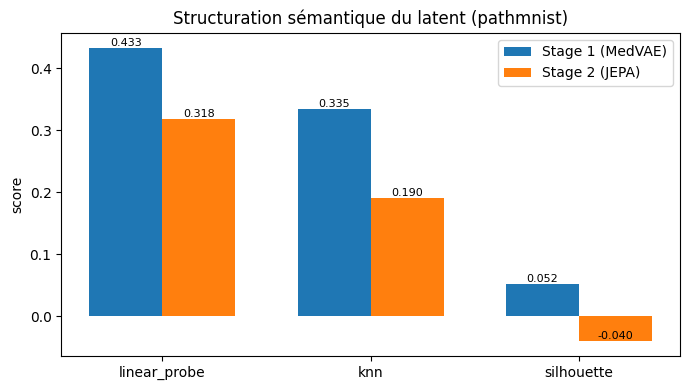

In [6]:
keys = list(m1.keys())
x = np.arange(len(keys))
w = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w / 2, [m1[k] for k in keys], w, label="Stage 1 (MedVAE)")
ax.bar(x + w / 2, [m2[k] for k in keys], w, label="Stage 2 (JEPA)")
ax.set_xticks(x)
ax.set_xticklabels(keys)
ax.set_ylabel("score")
ax.set_title(f"Structuration sémantique du latent ({DATASET})")
ax.legend()
for i, k in enumerate(keys):
    ax.text(i - w / 2, m1[k], f"{m1[k]:.3f}", ha="center", va="bottom", fontsize=8)
    ax.text(i + w / 2, m2[k], f"{m2[k]:.3f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

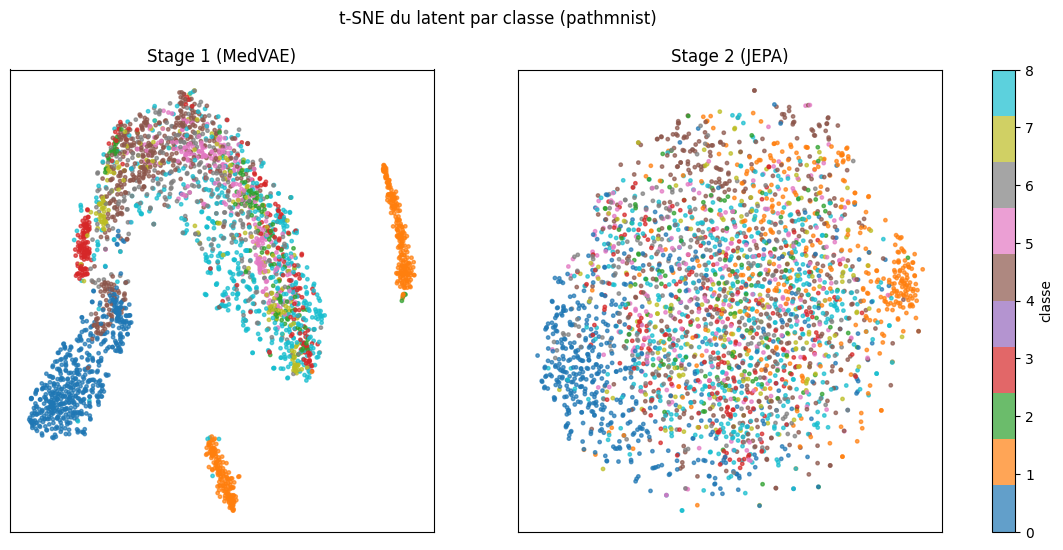

: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, X, y, title in [(axes[0], X1, y1, "Stage 1 (MedVAE)"), (axes[1], X2, y2, "Stage 2 (JEPA)")]:
    emb = TSNE(n_components=2, init="pca", perplexity=30, random_state=42).fit_transform(X)
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=y, cmap="tab10", s=6, alpha=0.7)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(sc, ax=axes, fraction=0.025, label="classe")
fig.suptitle(f"t-SNE du latent par classe ({DATASET})")
plt.show()